# Baseline Model 1: Naive Bayes with TF-IDF

Train and evaluate a Naive Bayes classifier on IMDb reviews using TF-IDF encoding.

In [2]:
# Step 1: Import all libraries

import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [3]:
# Step 2: Load pre-processed data

# Gets the absolute path to the data directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_path = os.path.join(parent_dir, "data", "cleaned_imdb_reviews.csv")

df = pd.read_csv(data_path)
print(df.shape)
df.head()

(2000, 3)


,review,label,cleaned_review
0,For a movie that gets no respect there sure ar...,1,movie get respect sure lot memorable quote lis...
1,Bizarre horror movie filled with famous faces ...,1,bizarre horror movie filled famous face stolen...
2,"A solid, if unremarkable film. Matthau, as Ein...",1,solid unremarkable film matthau einstein wonde...
3,It's a strange feeling to sit alone in a theat...,1,strange feeling sit alone theater occupied par...
4,"You probably all already know this by now, but...",1,probably already know 5 additional episode nev...


In [4]:
# Step 3: Train-test split

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 1600 Test size: 400


In [5]:
# Step 4: TF-IDF encoding

tfidif = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidif.fit_transform(X_train)
X_test_tfidf = tfidif.transform(X_test)

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)


TF-IDF Train shape: (1600, 5000)
TF-IDF Test shape: (400, 5000)


In [6]:
# Step 5: Train Naive Bayes model

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)

Y_pred = nb_model.predict(X_test_tfidf)

Accuracy: 0.825
Precision: 0.8000
Recall:    0.8643
F1 Score:  0.8309

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82       201
           1       0.80      0.86      0.83       199

    accuracy                           0.82       400
   macro avg       0.83      0.83      0.82       400
weighted avg       0.83      0.82      0.82       400



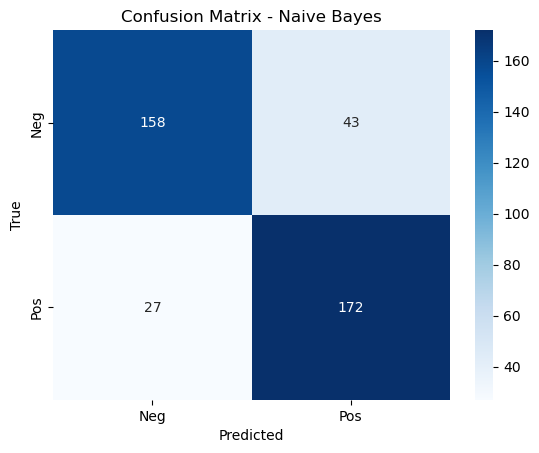

In [7]:
# Step 6: Evaluate the model
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion matrix

cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Naive Bayes")
plt.show() 